In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('cleaned_data_field_2.csv')
print("Dataset loaded successfully. Shape:", df.shape)

Dataset loaded successfully. Shape: (18829, 107)


In [6]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['age', 'height_cm', 'weight_kg', 'nationality', 'league_rank',
       'overall', 'potential', 'value_eur', 'wage_eur', 'preferred_foot',
       ...
       '#Playmaker', '#Poacher', '#Speedster', '#Strength', '#Tackling',
       '#Tactician', 'num_traits', 'Atk_effort', 'Def_effort',
       'player_versatility'],
      dtype='object', length=101)
Categorical columns: Index(['real_face', 'Att_position', 'Def_position', 'Mid_position',
       'RES_position', 'SUB_position'],
      dtype='object')


In [7]:
for col in numerical_cols:
    if np.any(np.isinf(df[col])) or np.any(df[col].isna()):
        print(f"Column {col} contains infinities or NaNs. Handling...")
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].fillna(df[col].median())
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print("Missing values and infinities handled.")

Column value_eur contains infinities or NaNs. Handling...
Column wage_eur contains infinities or NaNs. Handling...
Column release_clause_eur contains infinities or NaNs. Handling...
Column pace contains infinities or NaNs. Handling...
Column shooting contains infinities or NaNs. Handling...
Column passing contains infinities or NaNs. Handling...
Column dribbling contains infinities or NaNs. Handling...
Column defending contains infinities or NaNs. Handling...
Column physic contains infinities or NaNs. Handling...
Missing values and infinities handled.


In [8]:
drop_cols = ['release_clause_eur', 'wage_eur']
df = df.drop([col for col in drop_cols if col in df.columns], axis=1)
print("Dropped columns:", drop_cols) 

Dropped columns: ['release_clause_eur', 'wage_eur']


In [9]:
df['overall_age_ratio'] = df['overall'] / (df['age'] + 1)  # Avoid division by zero
df['skill_movement'] = df['skill_dribbling'] * df['movement_agility']
print("Feature engineering completed.")

Feature engineering completed.


In [10]:
if 'value_eur' in df.columns:
    correlations = df.select_dtypes(include=['int64', 'float64']).corr()['value_eur'].abs().sort_values(ascending=False)
    print("\nTop 5 features correlated with value_eur:")
    print(correlations.head(6))
else:
    print("Error: 'value_eur' column not found in dataset.")
    exit(1)


Top 5 features correlated with value_eur:
value_eur              1.000000
overall                0.936580
movement_reactions     0.798085
potential              0.761293
mentality_composure    0.672020
passing                0.620601
Name: value_eur, dtype: float64


In [11]:
y = np.log1p(y)
print("Target variable log-transformed.")

Target variable log-transformed.


In [12]:
if np.any(np.isinf(X)) or np.any(X.isna()):
    print("Error: Features contain infinities or NaNs after preprocessing.")
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())
    print("Infinities and NaNs fixed.")

In [13]:
scaler = StandardScaler()
try:
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    print("Features scaled successfully.")
except Exception as e:
    print(f"Error scaling features: {e}")
    exit(1)

Features scaled successfully.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets. X_train shape:", X_train.shape)

Data split into training and testing sets. X_train shape: (15063, 105)


In [15]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,  # Reduced from 5 to limit complexity
    reg_lambda=50.0,  # Increased regularization
    reg_alpha=5.0,  # Increased regularization
    subsample=0.8,
    colsample_bytree=0.7,  # Reduced to encourage feature diversity
    random_state=42
)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [16]:
y_pred = xgb_model.predict(X_test)

In [17]:
y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(y_pred)

In [18]:
rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
r2 = r2_score(y_test_exp, y_pred_exp)
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

RMSE: 0.02
R² Score: 0.94


In [19]:
feature_importance = xgb_model.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print("\nTop 5 Most Important Features:")
print(importance_df.head())


Top 5 Most Important Features:
               Feature  Importance
5              overall    0.331058
7             wage_eur    0.230369
33  movement_reactions    0.147460
6            potential    0.045528
64                  lm    0.039643


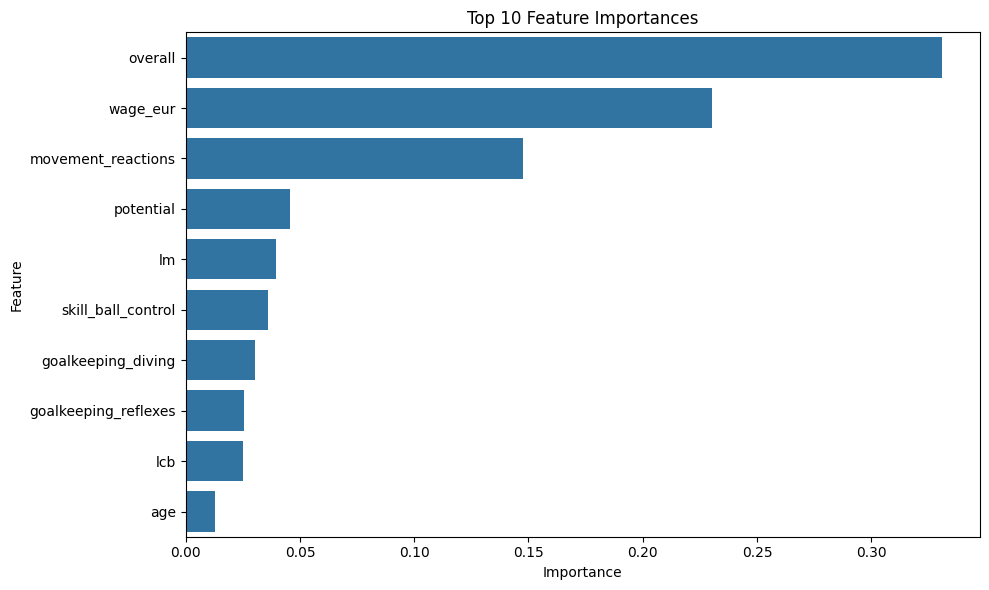

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()